In [75]:
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

# Define your model
model = get_model("resnet18", weights=get_model_weights("resnet18").DEFAULT).eval()
# Set your CAM extractor
cam_extractor = LayerCAM(model)

In [ ]:
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

# Get a model and an image
weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()
preprocess = weights.transforms()
img = decode_image("../data/Rottweiler_Dog.jpg")

input_tensor = preprocess(img)

with LayerCAM(model) as cam_extractor:
  out = model(input_tensor.unsqueeze(0))
  # Retrieve the CAM by passing the class index and the model output
  activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)

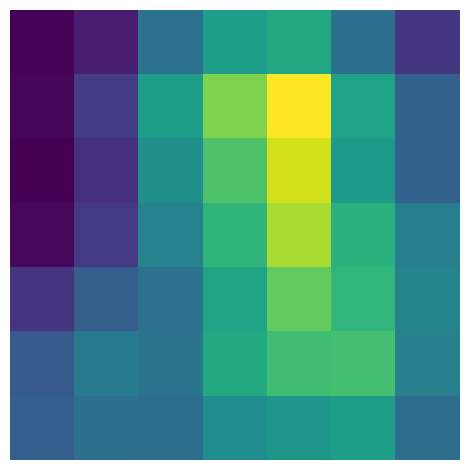

In [77]:
import matplotlib.pyplot as plt
# Visualize the raw CAM
plt.imshow(activation_map[0].squeeze(0).numpy()); plt.axis('off'); plt.tight_layout(); plt.show()

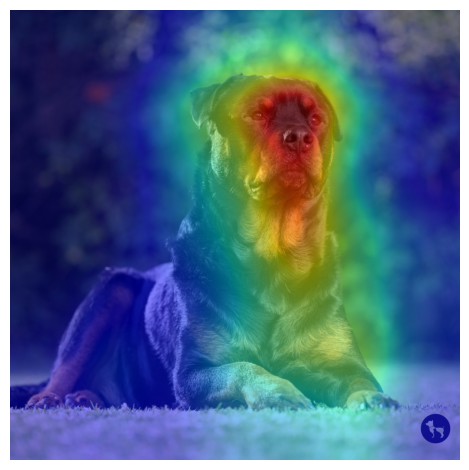

In [78]:
import matplotlib.pyplot as plt
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask

# Resize the CAM and overlay it
result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)
plt.imshow(result); plt.axis('off'); plt.tight_layout(); plt.show()

In [79]:

model.eval()
preprocess = weights.transforms()
batch = preprocess(img).unsqueeze(0)
prediction = model(batch).squeeze(0).softmax(0)


In [80]:
prediction.detach()

tensor([6.7051e-07, 1.2327e-07, 4.8647e-09, 1.0570e-08, 1.7951e-08, 2.2802e-07,
        2.5628e-08, 8.4929e-07, 3.0122e-07, 1.4755e-07, 1.6097e-06, 3.6475e-08,
        2.4280e-08, 7.3934e-08, 3.8217e-07, 3.5365e-06, 7.1419e-10, 2.5104e-08,
        5.0393e-08, 9.3068e-09, 9.2395e-08, 2.0681e-06, 5.3242e-07, 6.5383e-07,
        3.5780e-06, 3.6035e-06, 3.8583e-06, 2.5618e-06, 2.5201e-06, 2.8702e-08,
        1.1773e-07, 5.1453e-08, 2.1059e-07, 2.6567e-06, 1.2999e-06, 2.0206e-05,
        3.8147e-06, 3.3800e-06, 1.5327e-07, 7.7170e-07, 2.2386e-08, 1.1588e-07,
        3.3011e-07, 3.7037e-07, 2.1472e-07, 4.4392e-07, 8.1195e-08, 1.9995e-07,
        1.9857e-07, 3.7804e-07, 6.8174e-07, 5.5316e-07, 3.9921e-07, 3.2740e-07,
        2.8671e-07, 9.1687e-08, 8.2342e-08, 7.9635e-07, 6.9741e-07, 8.0165e-08,
        3.7117e-07, 6.1805e-07, 3.5702e-07, 2.0607e-06, 4.0049e-07, 5.0625e-07,
        1.7633e-07, 2.7000e-07, 2.2793e-07, 3.5153e-08, 3.2227e-08, 1.6586e-07,
        2.5338e-07, 1.1557e-07, 6.2508e-

In [81]:
#> claude.ai
#> I have a json file with class names (imagenet_class_index.json) from 1000 classes in ImageNet and an output 
#  tensor from a ResNet18 (with default pretrained weights) softmax operation. 
#  Give a function that maps the maximum logit in the output tensor to the class name from the json file.

import json
import torch


def predict_class(output_tensor: torch.Tensor, class_index_path: str) -> dict:
    """
    Maps the maximum logit in a softmax output tensor to an ImageNet class name.

    Args:
        output_tensor:    1D or 2D tensor of shape (1000,) or (1, 1000),
                          typically the output of a softmax layer from ResNet18.
        class_index_path: Path to the imagenet_class_index.json file.

    Returns:
        A dict with keys:
            - 'class_index'  (int)   : index of the predicted class (0–999)
            - 'class_id'     (str)   : WordNet synset ID, e.g. "n01440764"
            - 'class_name'   (str)   : human-readable label, e.g. "tench"
            - 'confidence'   (float) : softmax probability of the top class
    """
    with open(class_index_path, "r") as f:
        class_index = json.load(f)  # keys are str "0".."999"

    # Flatten to 1-D in case the tensor has a batch dimension
    probs = output_tensor.squeeze()          # (1000,)
    if probs.ndim != 1 or probs.shape[0] != 1000:
        raise ValueError(
            f"Expected a tensor of 1000 values, got shape {tuple(output_tensor.shape)}"
        )

    top_idx = int(probs.argmax())            # index of highest probability
    synset_id, class_name = class_index[str(top_idx)]

    return {
        "class_index": top_idx,
        "class_id":    synset_id,
        "class_name":  class_name,
        "confidence":  float(probs[top_idx]),
    }

In [82]:

predict_class(prediction, "/home/raphael/Downloads/imagenet_class_index.json")

{'class_index': 234,
 'class_id': 'n02106550',
 'class_name': 'Rottweiler',
 'confidence': 0.9174426794052124}